Data loaded
Beginning Training
Epoch:1 / 10, train loss: 0.4842, train metric: 0.8476, valid metric: 0.9580 (best) in 48.5s
Epoch:2 / 10, train loss: 0.2091, train metric: 0.9350, valid metric: 0.9732 (best) in 47.8s
Epoch:3 / 10, train loss: 0.1642, train metric: 0.9485, valid metric: 0.9712 in 47.8s
Epoch:4 / 10, train loss: 0.1371, train metric: 0.9573, valid metric: 0.9822 (best) in 47.8s
Epoch:5 / 10, train loss: 0.1247, train metric: 0.9609, valid metric: 0.9788 in 47.9s
Epoch:6 / 10, train loss: 0.1181, train metric: 0.9626, valid metric: 0.9868 (best) in 47.8s
Epoch:7 / 10, train loss: 0.1107, train metric: 0.9658, valid metric: 0.9850 in 47.7s
Epoch:8 / 10, train loss: 0.1005, train metric: 0.9687, valid metric: 0.9836 in 48.1s
Epoch:9 / 10, train loss: 0.0978, train metric: 0.9693, valid metric: 0.9866 in 47.7s
Epoch:10 / 10, train loss: 0.0895, train metric: 0.9721, valid metric: 0.9814 in 47.6s


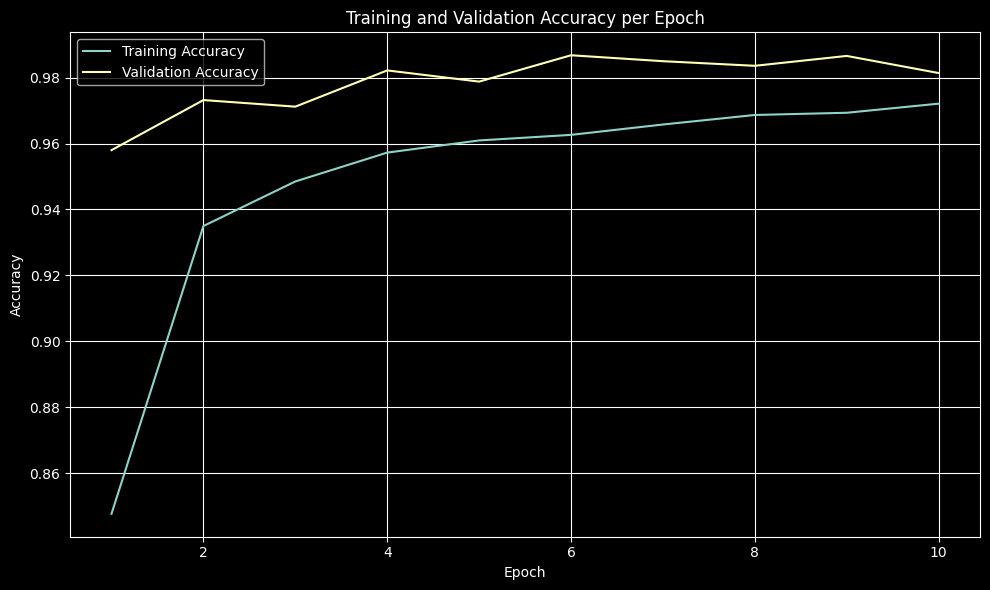

Finished Training
tensor(0.9922, device='mps:0')


In [1]:
from MnistModel import MnistEnsembleModel, CLASS_COUNT
from ModelRunner import OneCycleModelRunner
from graph_history import graph_history
from torch import nn

import mnist_loading
import torch
import torchmetrics

train_loader, valid_loader, test_loader = mnist_loading.with_image_augmentation()
print("Data loaded")

torch.manual_seed(42)

mnist_model = MnistEnsembleModel(3)
optimizer = torch.optim.Adam(mnist_model.parameters())
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=CLASS_COUNT)

print("Beginning Training")
runner = OneCycleModelRunner(mnist_model, accuracy, optimizer, xentropy)
history = runner.train_model(train_loader, valid_loader, n_epochs=10)
graph_history(history)
print("Finished Training")

print(runner.run_model(test_loader))
